# Thesis Project: Leveraging Topological Data Analysis to Identify Early Warning Signals in Financial Markets

In [19]:
import yfinance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils import build_point_clouds, compute_lp_norms, detect_signals, get_signal_date
import plotly.io as pio
import plotly.graph_objects as go
from gtda.plotting import plot_point_cloud, plot_diagram
from gtda.homology import VietorisRipsPersistence
import gudhi as gd
from gtda.diagrams import PersistenceLandscape
from scipy.integrate import simpson

In [20]:
# Date range
start_date = "1999-01-04"
end_date = "2021-01-01"

In [21]:
# Global style for matplotlib plots
plt.style.use("seaborn-v0_8-whitegrid")  
plt.rcParams.update({
    'figure.figsize': (10, 8),
    'axes.titlesize': 16,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'lines.linewidth': 1.5
})

In [22]:
# Layout for plotly
custom_template = go.layout.Template(
    layout=go.Layout(
        font=dict(size=12),
        title=dict(font=dict(size=20)),
        xaxis=dict(
            title_font=dict(size=16),
            tickfont=dict(size=10)
        ),
        yaxis=dict(
            title_font=dict(size=16),
            tickfont=dict(size=10)
        ),
        legend=dict(font=dict(size=14))
    )
)

# Apply as default
pio.templates["custom_thesis"] = custom_template
pio.templates.default = "custom_thesis+plotly_white"


# Step 1: Retrieve data 

In [23]:
DAX = yfinance.Ticker("^GDAXI")
hist = DAX.history(start=start_date, end=end_date)
dax_df = hist['Close']

FTSE100 = yfinance.Ticker("^FTSE")
hist = FTSE100.history(start=start_date, end=end_date)
ftse100_df = hist['Close']

CAC40 = yfinance.Ticker("^FCHI")
hist = CAC40.history(start=start_date, end=end_date)
cac40_df = hist['Close']

IBEX35 = yfinance.Ticker("^IBEX")
hist = IBEX35.history(start=start_date, end=end_date)
ibex35_df = hist['Close']

In [24]:
dax_df = dax_df.rename("DAX")
ftse100_df = ftse100_df.rename("FTSE 100")
cac40_df = cac40_df.rename("CAC 40")
ibex35_df = ibex35_df.rename("IBEX 35")

eu_df = pd.concat([dax_df, ftse100_df, cac40_df, ibex35_df], axis=1)
eu_df.index = pd.to_datetime(eu_df.index).date
eu_df = eu_df.groupby(eu_df.index).last()

In [25]:
eu_df.head()

,DAX,FTSE 100,CAC 40,IBEX 35
1999-01-03,5290.359863,NaN,4147.500000,10447.789062
1999-01-04,5263.410156,5879.399902,4200.779785,10650.689453
1999-01-05,5442.899902,5958.200195,4294.819824,NaN
1999-01-06,5345.709961,6148.799805,4230.669922,10443.389648
1999-01-07,5370.509766,6101.200195,4245.419922,10412.289062


In [26]:
eu_df.tail()

,DAX,FTSE 100,CAC 40,IBEX 35
2020-12-27,13790.290039,NaN,5588.379883,8155.600098
2020-12-28,13761.379883,NaN,5611.790039,8174.799805
2020-12-29,13718.780273,6602.700195,5599.410156,8154.399902
2020-12-30,NaN,6555.799805,5551.410156,8073.700195
2020-12-31,NaN,6460.500000,NaN,NaN


In [27]:
eu_df.isna().sum()

DAX         555
FTSE 100    577
CAC 40      517
IBEX 35     551
dtype: int64

In [28]:
len(eu_df)

6135

In [29]:
eu_df.dropna(inplace=True)
len(eu_df)

4986

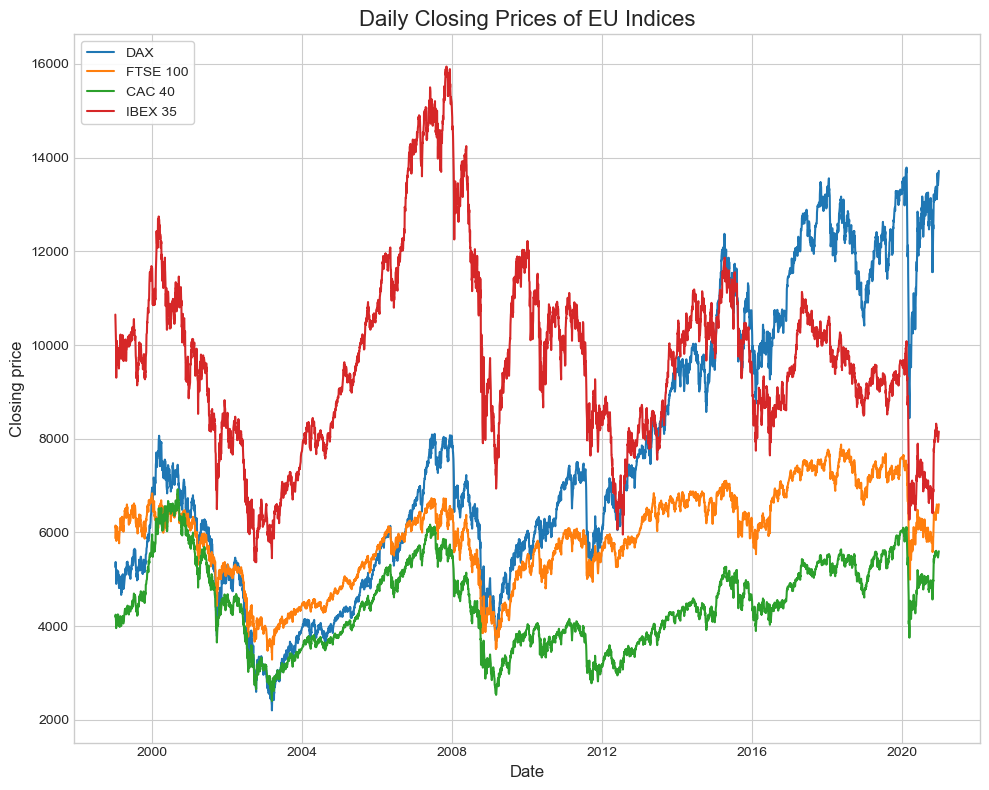

In [30]:
eu_df.plot()
plt.title("Daily Closing Prices of EU Indices")
plt.xlabel("Date")
plt.ylabel("Closing price")
plt.legend(loc="upper left", frameon=True, framealpha=0.9)
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/eu_closing_price.png", dpi=300)
plt.show()

## Compute daily log returns 

In [31]:
eu_df = np.log(eu_df / eu_df.shift(1))

In [32]:
eu_df.head()

,DAX,FTSE 100,CAC 40,IBEX 35
1999-01-04,NaN,NaN,NaN,NaN
1999-01-06,0.015515,0.044802,0.007090,-0.019655
1999-01-07,0.004628,-0.007771,0.003480,-0.002982
1999-01-11,-0.033009,-0.002659,-0.034683,-0.039353
1999-01-12,-0.042059,-0.008483,-0.035237,-0.071290


In [33]:
eu_df.tail()

,DAX,FTSE 100,CAC 40,IBEX 35
2020-12-15,0.015085,-0.002836,0.003136,-0.001584
2020-12-16,0.007437,0.008805,0.000321,0.001706
2020-12-17,-0.002692,-0.003018,-0.003904,-0.014329
2020-12-21,-0.015705,-0.020791,-0.011093,-0.012923
2020-12-29,0.022160,0.028637,0.023957,0.027375


In [34]:
eu_df.isna().sum()

DAX         1
FTSE 100    1
CAC 40      1
IBEX 35     1
dtype: int64

In [35]:
eu_df = eu_df.dropna()

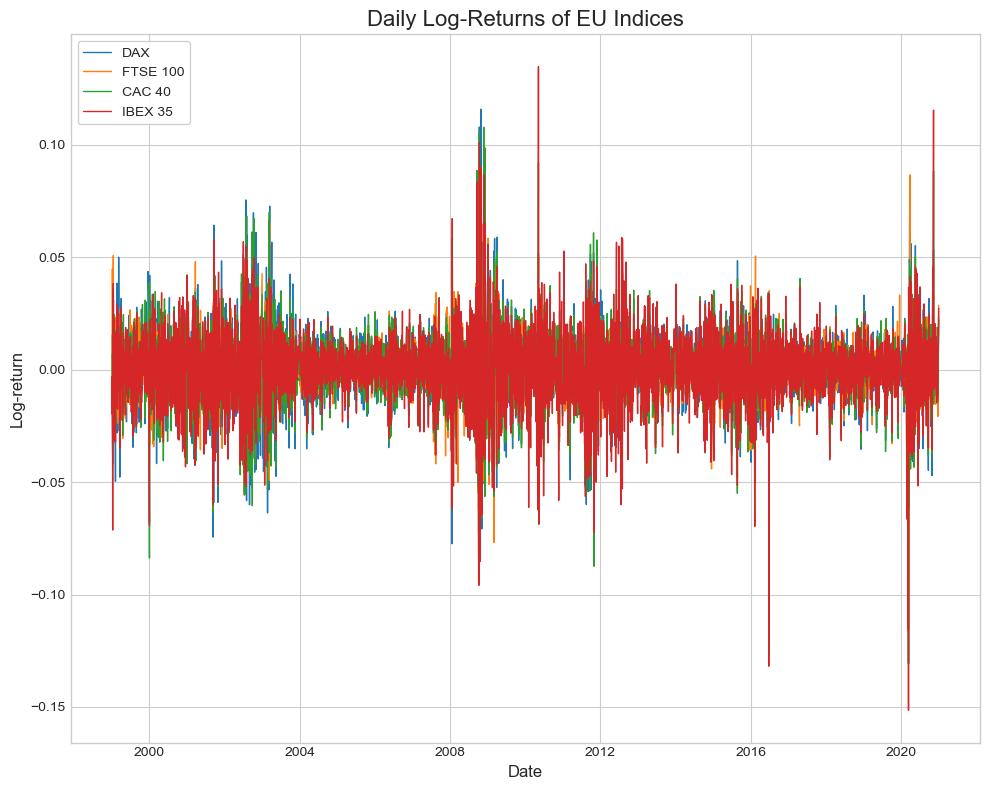

In [36]:
eu_df.plot(linewidth=1)
plt.title("Daily Log-Returns of EU Indices")
plt.xlabel("Date")
plt.ylabel("Log-return")
plt.legend(loc="upper left", frameon=True, framealpha=0.9)
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/eu_log_returns.png", dpi=300)
plt.show()

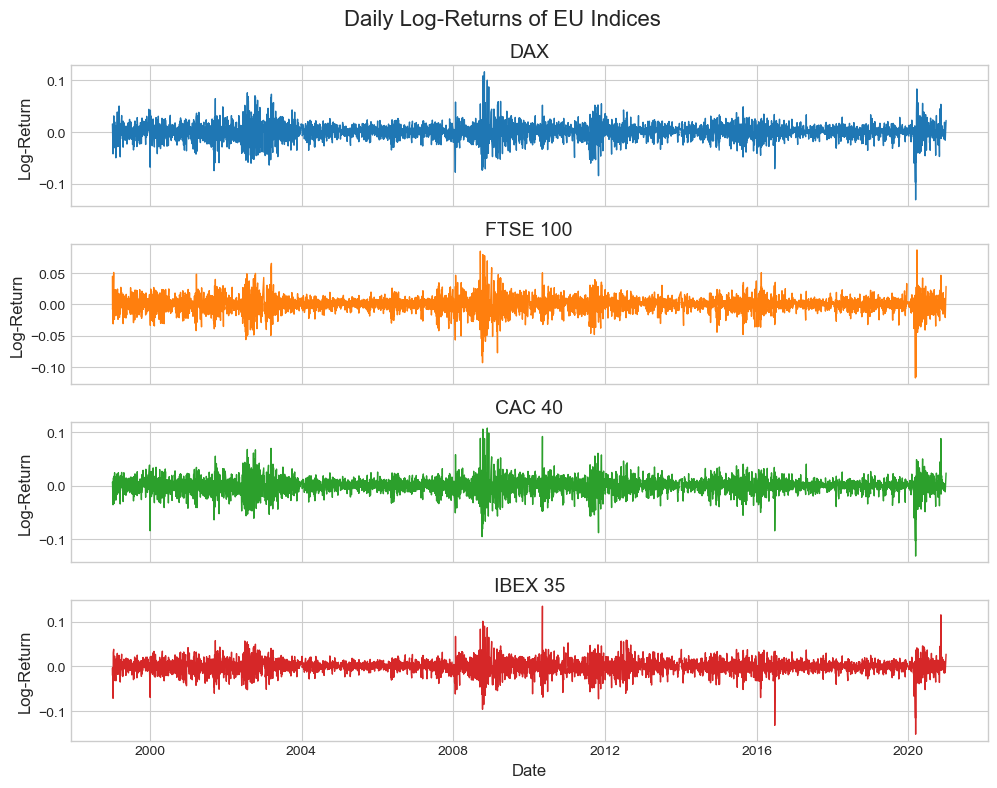

In [37]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 8), sharex=True)
indices = ["DAX", "FTSE 100", "CAC 40", "IBEX 35"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for i, index in enumerate(indices):
    eu_df[index].plot(ax=axes[i], color=colors[i], linewidth=1)
    axes[i].set_ylabel("Log-Return", fontsize=12)
    axes[i].set_title(f"{index}", fontsize=14)
    axes[i].grid(True)

# Set common x-label
axes[-1].set_xlabel("Date", fontsize=12)

plt.suptitle("Daily Log-Returns of EU Indices", fontsize=16)
plt.tight_layout()
plt.savefig("Figures/eu_log_returns_subplots.png", dpi=300)
plt.show()

# Step 2: Create point clouds

In [38]:
eu_cloud_30 = build_point_clouds(eu_df, 30)
eu_cloud_30

[array([[ 1.55152274e-02,  4.48022098e-02,  7.09018330e-03,
         -1.96554187e-02],
        [ 4.62846966e-03, -7.77140391e-03,  3.48038191e-03,
         -2.98245954e-03],
        [-3.30087372e-02, -2.65877872e-03, -3.46829979e-02,
         -3.93531826e-02],
        [-4.20585684e-02, -8.48286273e-03, -3.52370052e-02,
         -7.12895778e-02],
        [-1.60592546e-02, -3.08850919e-02,  9.63837224e-03,
         -1.87910631e-03],
        [ 1.43837990e-02, -5.12411284e-03,  1.43447397e-02,
          3.09116870e-02],
        [ 1.29184627e-02,  5.08644735e-02,  1.49756002e-02,
          3.83735517e-02],
        [ 3.10118458e-02, -1.58501948e-02,  1.78236193e-02,
          1.18036173e-02],
        [-6.50538107e-03,  1.28574611e-02, -8.62416897e-03,
         -1.69211794e-02],
        [-3.05264405e-02, -1.37371851e-02, -3.29636542e-02,
         -3.16212573e-02],
        [-1.40268563e-03, -2.37594189e-02,  1.28422120e-02,
         -2.33318307e-03],
        [ 7.37498012e-03,  8.15918480e-04, 

### Identify a quiet period

In [ ]:
# Find the date with the smallest absolute value of log return 
quiet_loc = eu_df.abs().stack().idxmin()
quiet_loc

(datetime.date(2002, 1, 21), 'FTSE 100')

In [ ]:
quiet_date = quiet_loc[0]   # Extract the date
quiet_position = eu_df.index.get_loc(quiet_date)  # Get the row index of that date
quiet_window = max(0, quiet_position - 30 + 1)  # Get the start of the window ending at that date
quiet_window

649

### Identify a critical period

In [ ]:
# Find the location of the lowest log return 
critical_loc = eu_df.stack().idxmin()
critical_loc

(datetime.date(2020, 3, 11), 'IBEX 35')

In [ ]:
critical_date = critical_loc[0]    # Extract the date
critical_position = eu_df.index.get_loc(critical_date)   # Get the row index of that date
critical_window = max(0, critical_position - 30 + 1)    # Get the start of the window ending at that date
critical_window

4769

In [ ]:
cloud = eu_cloud_30[649]
fig = plot_point_cloud(cloud, 2)

fig.update_layout(
    width=800, 
    height=700,
    title=dict(text="Point Cloud of EU Indices - Window 649", x=0.5,
            xanchor="center")
)
fig.update_traces(marker=dict(color="#2ca02c", size=8)) 

fig.show()
fig.write_image("Figures/eu_cloud_649.png", scale=3)

In [ ]:
cloud = eu_cloud_30[4769]
fig = plot_point_cloud(cloud, 2)

fig.update_layout(
    width=800, 
    height=700,
    title=dict(text="Point Cloud of EU Indices - Window 4769", x=0.5,
            xanchor="center")
)
fig.update_traces(marker=dict(color="#2ca02c", size=8)) 

fig.show()
fig.write_image("Figures/eu_cloud_4769.png", scale=3)

## Step 3: Compute Persistence Diagrams and Barcodes

In [ ]:
# Initialize the Vietoris–Rips persistence object from Giotto-TDA
VR = VietorisRipsPersistence(
    metric='euclidean',        # Use Euclidean distance to compute pairwise distances between points in each cloud
    homology_dimensions=[0, 1],    # Compute 0D (connected components) and 1D (loops) persistence features
    max_edge_length=0.15,          # Restrict simplicial complex to edges with length ≤ 0.15
    collapse_edges=False,          # Do not apply edge collapsing
    n_jobs=-1                      # Use all available CPU cores for parallel computation
)

# Compute persistence diagrams
eu_diagram = VR.fit_transform(eu_cloud_30)

In [47]:
eu_diagram

array([[[0.        , 0.00282056, 0.        ],
        [0.        , 0.00655649, 0.        ],
        [0.        , 0.00916315, 0.        ],
        ...,
        [0.00252621, 0.00252621, 1.        ],
        [0.00252621, 0.00252621, 1.        ],
        [0.00252621, 0.00252621, 1.        ]],

       [[0.        , 0.00282056, 0.        ],
        [0.        , 0.00655649, 0.        ],
        [0.        , 0.00916315, 0.        ],
        ...,
        [0.00252621, 0.00252621, 1.        ],
        [0.00252621, 0.00252621, 1.        ],
        [0.00252621, 0.00252621, 1.        ]],

       [[0.        , 0.00282056, 0.        ],
        [0.        , 0.00655649, 0.        ],
        [0.        , 0.00916315, 0.        ],
        ...,
        [0.00252621, 0.00252621, 1.        ],
        [0.00252621, 0.00252621, 1.        ],
        [0.00252621, 0.00252621, 1.        ]],

       ...,

       [[0.        , 0.00199785, 0.        ],
        [0.        , 0.00286064, 0.        ],
        [0.        , 0

In [ ]:
fig = plot_diagram(eu_diagram[649])

fig.update_layout(
    width=800, 
    height=700,
    title=dict(text="Persistence Diagram of EU Indices - Window 649", x=0.5,
            xanchor="center"),
    legend=dict(
        title="Homology Class",
        font=dict(size=13), 
        bordercolor="lightgray",         
        borderwidth=0.7                
    )
)

for trace in fig.data:
    if trace.mode == 'markers':
        trace.marker.size = 10
        if "H0" in trace.name:
            trace.marker.color = "#d62728"
            trace.name = "H\u2080"  
        elif "H1" in trace.name:
            trace.marker.color = "#1f77b4"
            trace.name = "H\u2081"  

fig.show()
fig.write_image("Figures/eu_diagram_649.png", scale=3)

In [ ]:
fig = plot_diagram(eu_diagram[4769])

fig.update_layout(
    width=800, 
    height=700,
    title=dict(text="Persistence Diagram of EU Indices - Window 4769", x=0.5,
            xanchor="center"),
    legend=dict(
        title="Homology Class",
        font=dict(size=13), 
        bordercolor="lightgray",         
        borderwidth=0.7               
    )
)

for trace in fig.data:
    if trace.mode == 'markers':
        trace.marker.size = 10
        if "H0" in trace.name:
            trace.marker.color = "#d62728"
            trace.name = "H\u2080"  
        elif "H1" in trace.name:
            trace.marker.color = "#1f77b4"
            trace.name = "H\u2081"  

fig.show()
fig.write_image("Figures/eu_diagram_4769.png", scale=3)

/opt/anaconda3/envs/tda_env_2/lib/python3.10/site-packages/gudhi/persistence_graphical_tools.py:129: UserWarning:

usetex mode requires TeX.



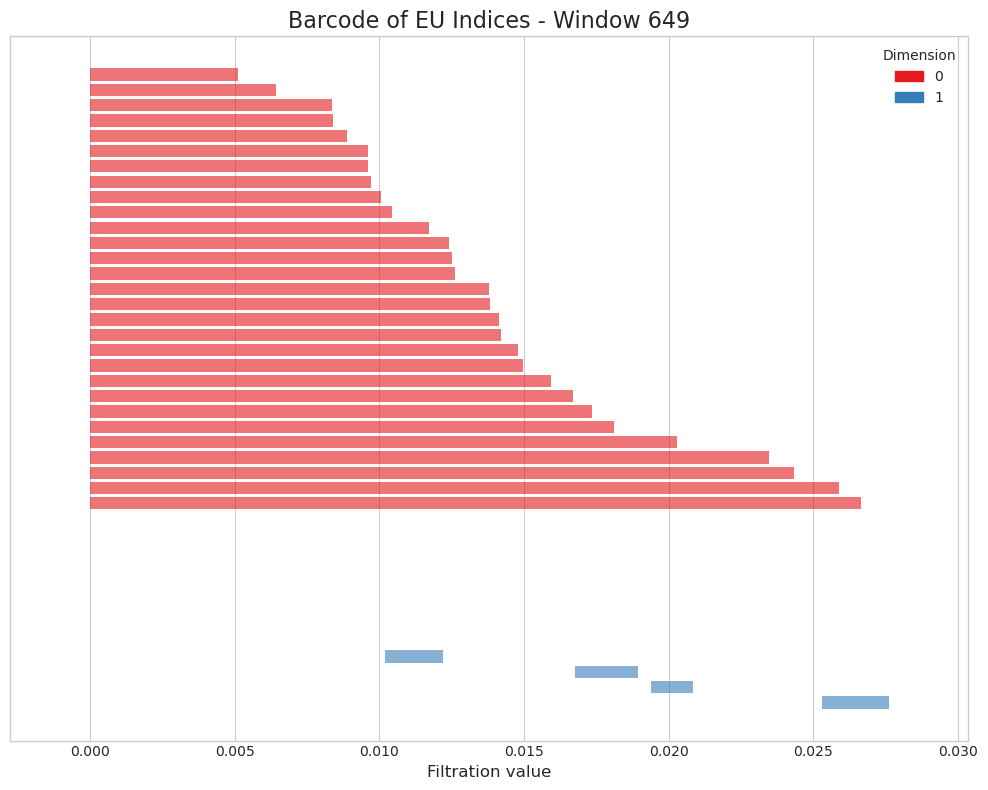

In [ ]:
# Convert the diagram into the GUDHI-compatible format for plotting
# Each entry is a tuple: (dimension, (birth, death))
# - dim: homology dimension (0 or 1)
# - b, d: birth and death filtration values
diagram = eu_diagram[649]
gudhi_format = [(int(dim), (float(b), float(d))) for b, d, dim in diagram]
gd.plot_persistence_barcode(gudhi_format, legend=True)
plt.title("Barcode of EU Indices - Window 649")
plt.xlabel("Filtration value")
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/eu_barcode_649.png", dpi=300)
plt.show()

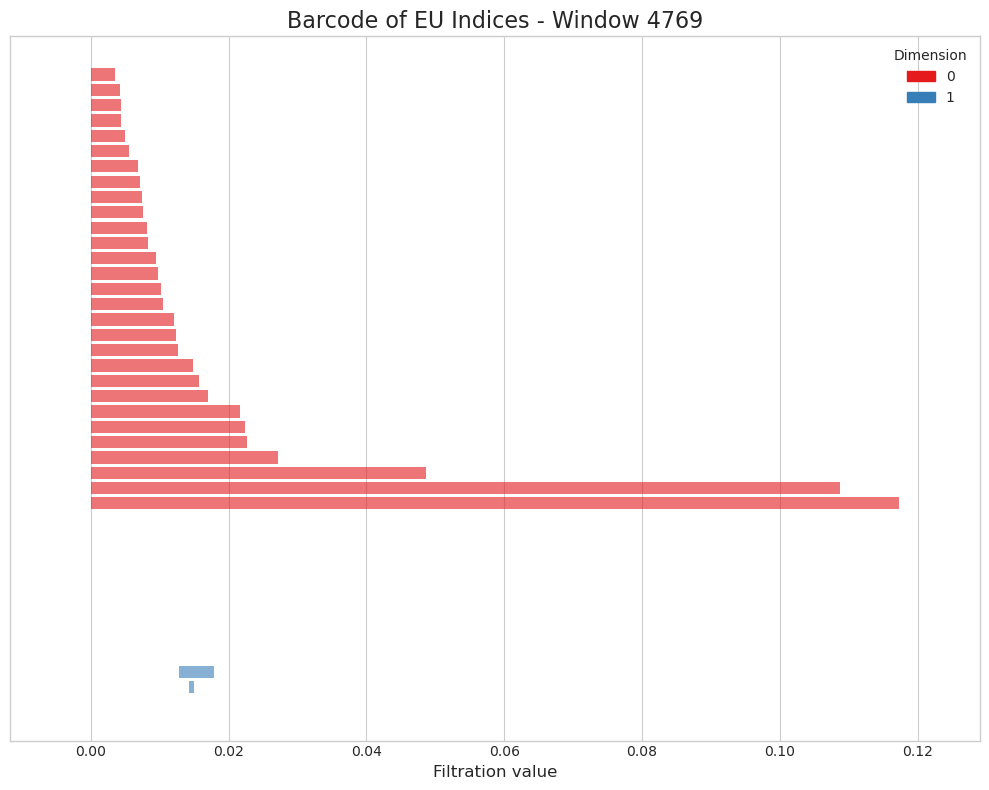

In [51]:
diagram = eu_diagram[4769]
gudhi_format = [(int(dim), (float(b), float(d))) for b, d, dim in diagram]
gd.plot_persistence_barcode(gudhi_format, legend=True)
plt.title("Barcode of EU Indices - Window 4769")
plt.xlabel("Filtration value")
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/eu_barcode_4769.png", dpi=300)
plt.show()

## Step 4: Compute Persistent Landscapes

In [ ]:
# Initialize the Persistence Landscape transformer from Giotto-TDA
# - n_layers: number of landscape layers to compute (captures the most prominent topological features)
# - n_jobs=-1: uses all available cores
PL = PersistenceLandscape(n_layers=5, n_jobs=-1)
eu_landscapes = PL.fit_transform(eu_diagram)

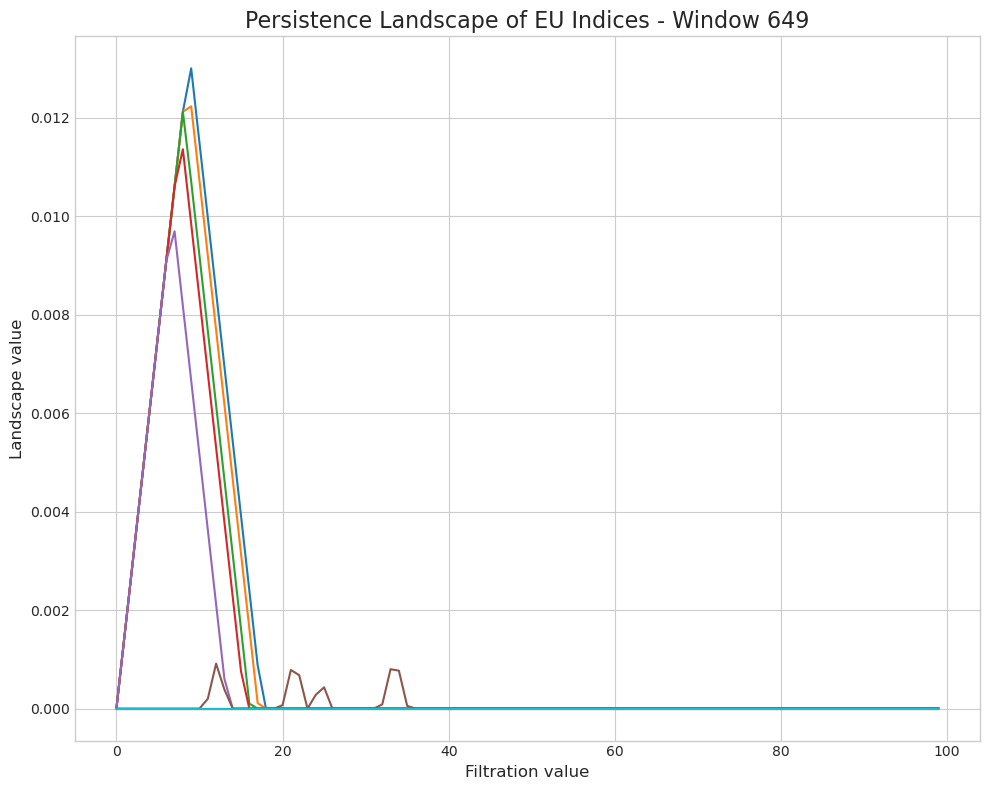

In [53]:
plt.plot(eu_landscapes[649].T)
plt.title("Persistence Landscape of EU Indices - Window 649")
plt.xlabel("Filtration value")
plt.ylabel("Landscape value")
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/eu_landscape_649.png", dpi=300)
plt.show()

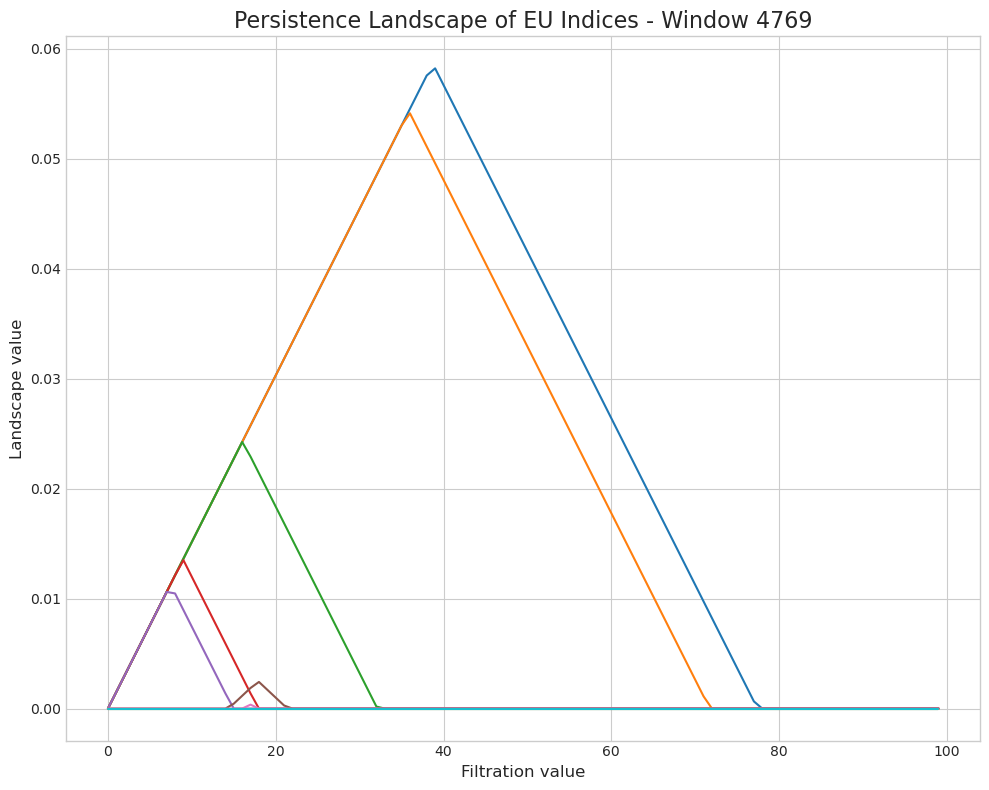

In [54]:
plt.plot(eu_landscapes[4769].T)
plt.title("Persistence Landscape of EU Indices - Window 4769")
plt.xlabel("Filtration value")
plt.ylabel("Landscape value")
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/eu_landscape_4769.png", dpi=300)
plt.show()


## Step 5: Compute L^p Norms

In [ ]:
all_births = []
all_deaths = []

# Loop over each persistence diagram and collect birth/death times
for diagram in eu_diagram:
    all_births.extend(diagram[:, 0])
    all_deaths.extend(diagram[:, 1])

# Determine the overall range of the filtration values across all diagrams
start = min(all_births)
end = max(all_deaths)

# Extract the number of bins used in each landscape layer
n_bins = eu_landscapes[0].shape[1]
# Compute the grid spacing over the interval [start, end] - for Simpson's rule 
dx = (end - start) / (n_bins - 1)

l1_norms = compute_lp_norms(eu_landscapes, p=1, dx=dx)
l2_norms = compute_lp_norms(eu_landscapes, p=2, dx=dx)

In [ ]:
# Detect warning signals in the L1 norm time series 
warning_days_l1 = detect_signals(l1_norms, alpha=1.4, beta=3, s=40, t=250)

# Convert signal indices into actual calendar dates adn get the first day of each burst of consecutive warnings
dates = eu_df.index[30 - 1:]         # Align the norm indices with the original DataFrame's dates
signals_l1 = get_signal_date(warning_days_l1, dates)

for d in signals_l1:
    print(d)

2008-01-21
2008-09-18
2010-05-09
2016-06-23
2020-02-24


In [ ]:
# Detect warning signals in the L2 norm time series 
warning_days_l2 = detect_signals(l2_norms, alpha=1.4, beta=3, s=40, t=250)
signals_l2 = get_signal_date(warning_days_l2, dates)

for d in signals_l2:
    print(d)

2008-01-21
2008-09-18
2010-05-09
2016-06-23
2020-02-24


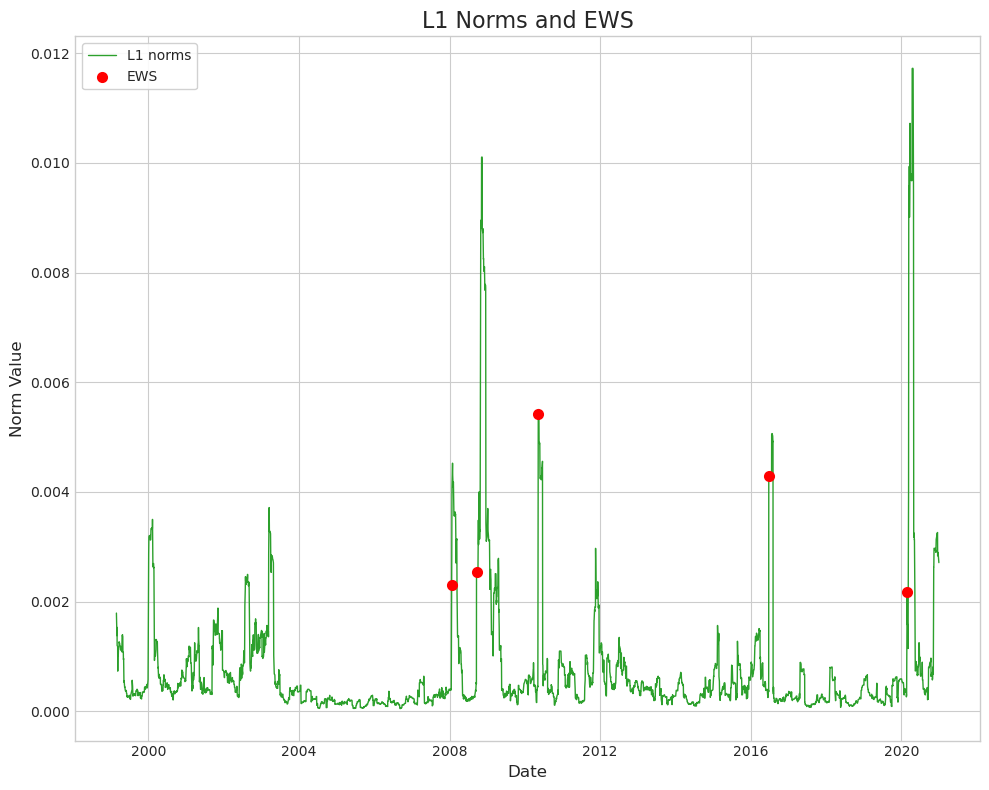

In [59]:
signal_positions = [dates.get_loc(date) for date in signals_l1]
plt.plot(dates, l1_norms, label='L1 norms', color='#2ca02c', linewidth=1, zorder=1)
plt.scatter(signals_l1, l1_norms[signal_positions], color='red', label='EWS', marker='o', linewidths=2, zorder=2)
plt.title("L1 Norms and EWS")
plt.xlabel("Date")
plt.ylabel("Norm Value")
plt.legend(loc="upper left", frameon=True, framealpha=0.9)
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/eu_l1_norms.png", dpi=300)
plt.show()


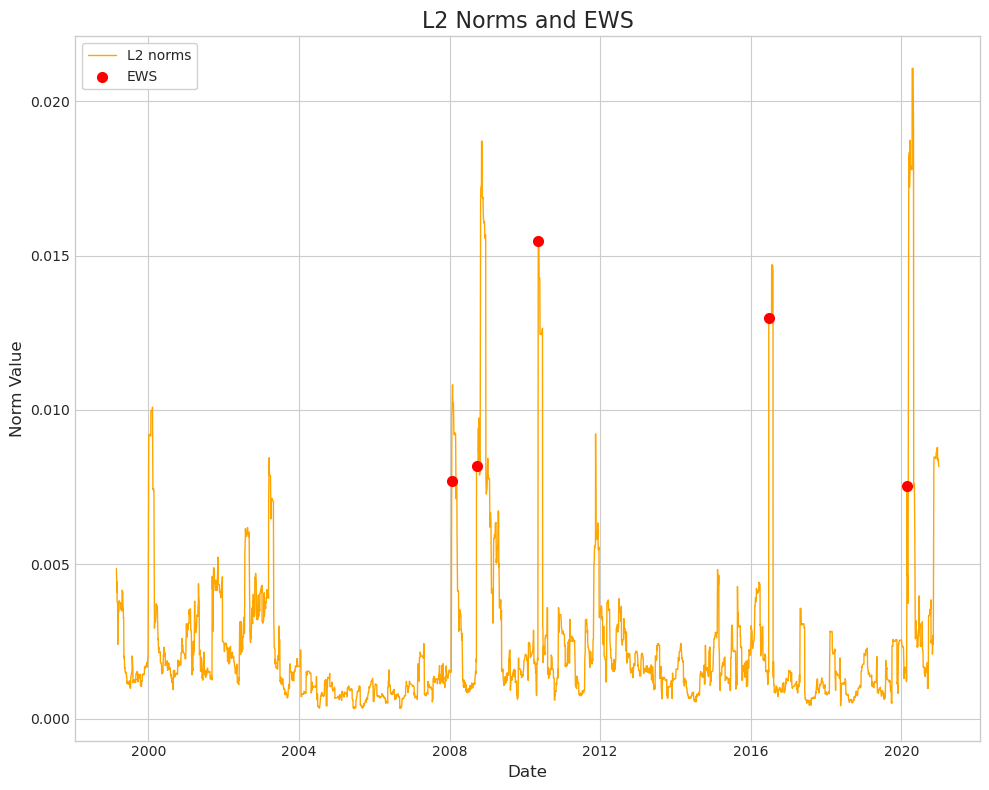

In [60]:
signal_positions = [dates.get_loc(date) for date in signals_l2]
plt.plot(dates, l2_norms, label='L2 norms', color='orange', linewidth=1, zorder=1)
plt.scatter(signals_l2, l2_norms[signal_positions], color='red', label='EWS', marker='o', linewidths=2, zorder=2)
plt.title("L2 Norms and EWS")
plt.xlabel("Date")
plt.ylabel("Norm Value")
plt.legend(loc="upper left", frameon=True, framealpha=0.9)
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/eu_l2_norms.png", dpi=300)
plt.show()
